In [2]:
from google.colab import files

uploaded = files.upload()

Saving titanic.csv to titanic.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("titanic.csv")
print("First 5 rows of the dataset:")
display(df.head())
print("\nShape of dataset (rows, columns):", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

df['Survival_Flag'] = df['survived']
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']

First 5 rows of the dataset:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



Shape of dataset (rows, columns): (891, 15)

Column names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-

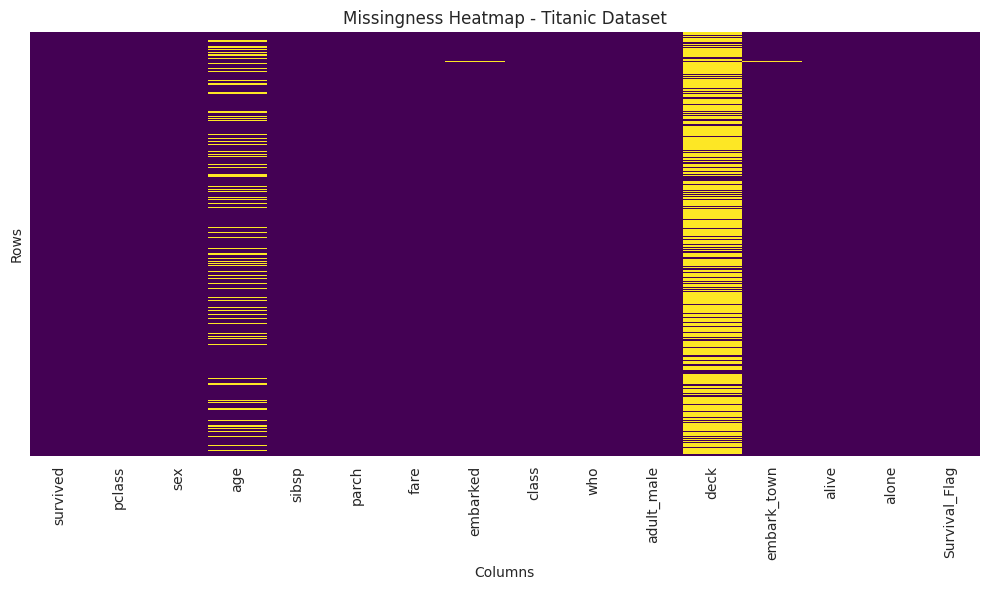

In [5]:
fig1 = plt.figure(figsize=(10, 6))

sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)

plt.title("Missingness Heatmap - Titanic Dataset")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

Numeric columns: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'Survival_Flag']


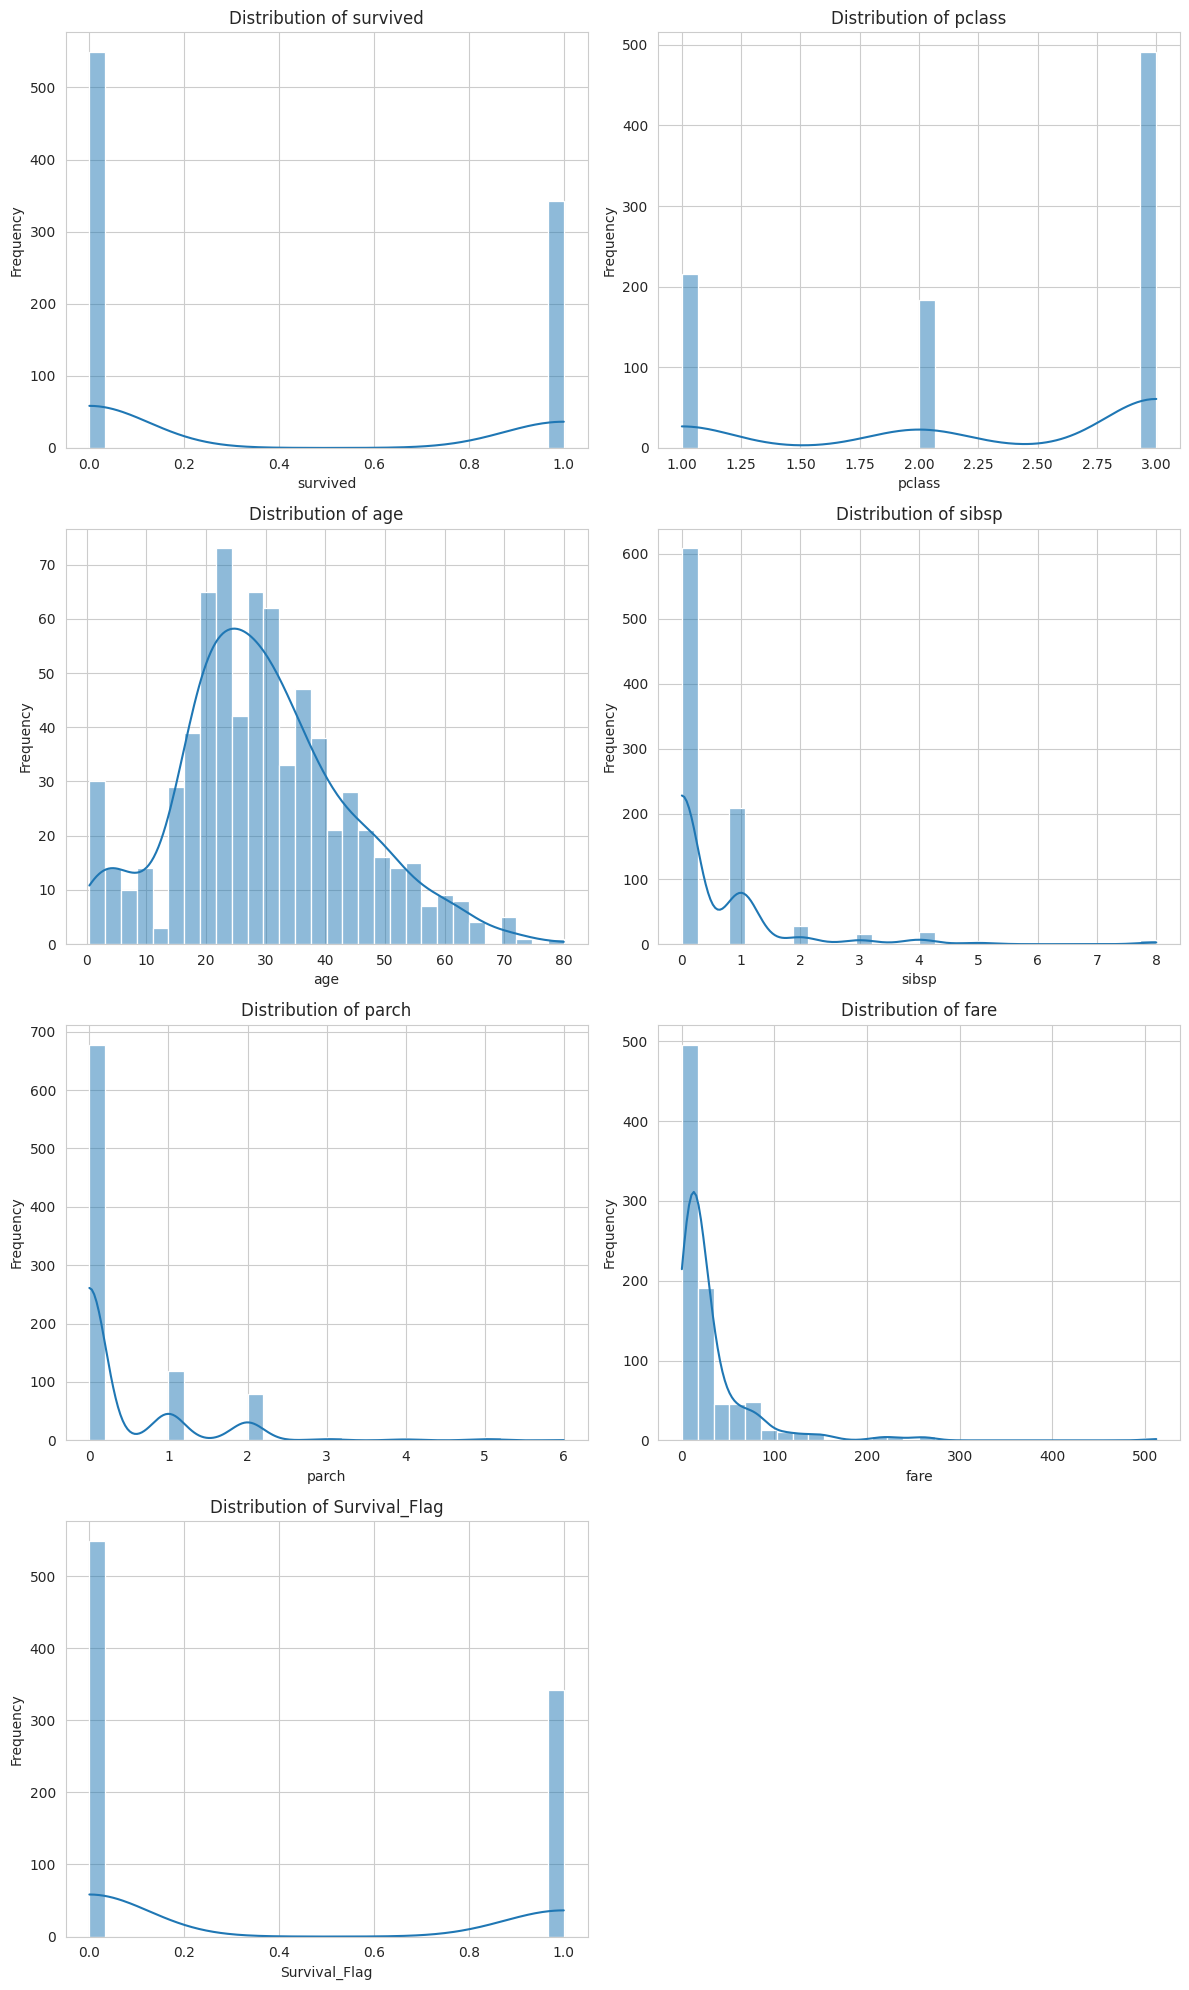

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

num_cols = df.select_dtypes(include=['number']).columns.tolist()

print("Numeric columns:", num_cols)

n = len(num_cols)

cols = 2
rows = math.ceil(n / cols)

fig2, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        df[col].dropna(),
        bins=30,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for j in range(len(num_cols), len(axes)):
    fig2.delaxes(axes[j])

plt.tight_layout()
plt.show()

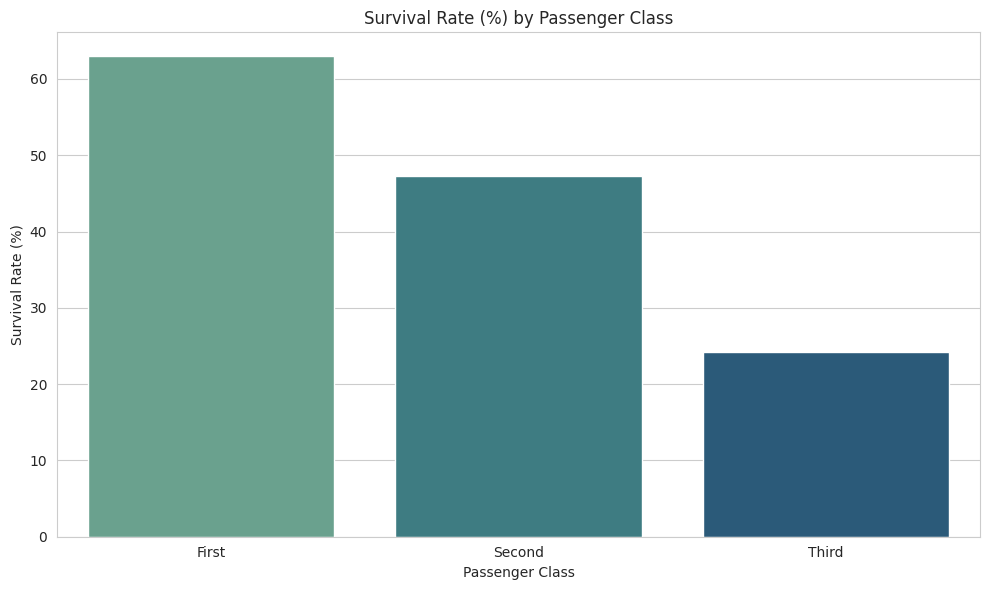


Survival rate (%) by passenger class:
class
First     62.96
Second    47.28
Third     24.24
Name: survived, dtype: float64


In [14]:
fig3 = plt.figure(figsize=(10, 6))

survival_rate = (
    df.groupby('class')['survived'].mean().sort_values(ascending=False) * 100
)

sns.barplot(
    x=survival_rate.index,
    y=survival_rate.values,
    hue=survival_rate.index,
    palette="crest",
    legend=False
)

plt.title('Survival Rate (%) by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.tight_layout()
plt.show()

print("\nSurvival rate (%) by passenger class:")
print(survival_rate.round(2))

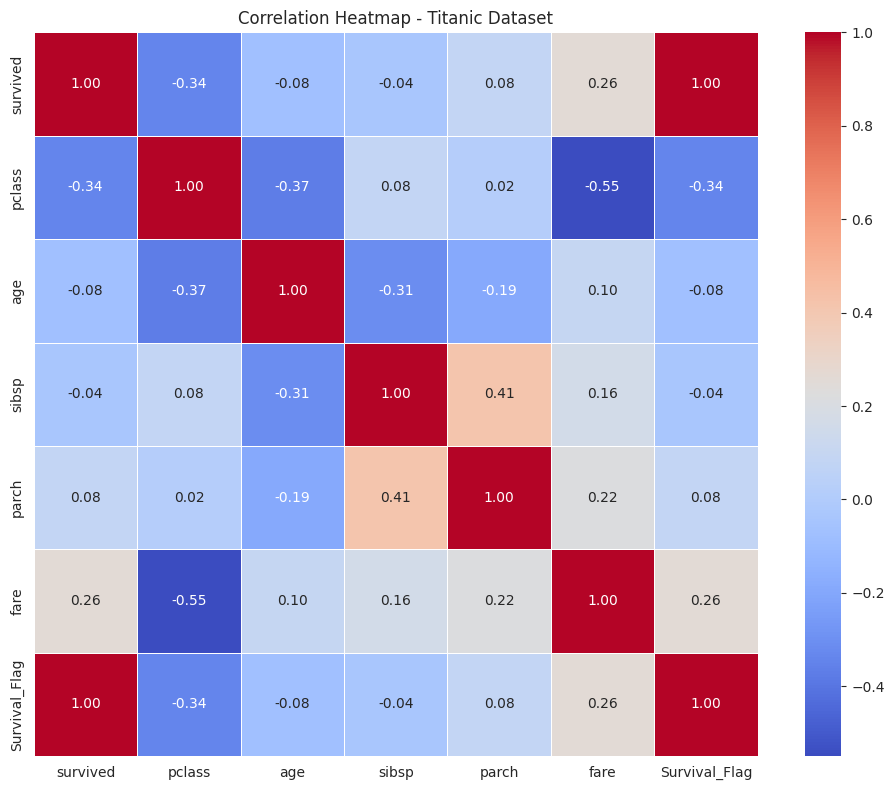

In [15]:
fig4 = plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5
)

plt.title('Correlation Heatmap - Titanic Dataset')
plt.tight_layout()
plt.show()

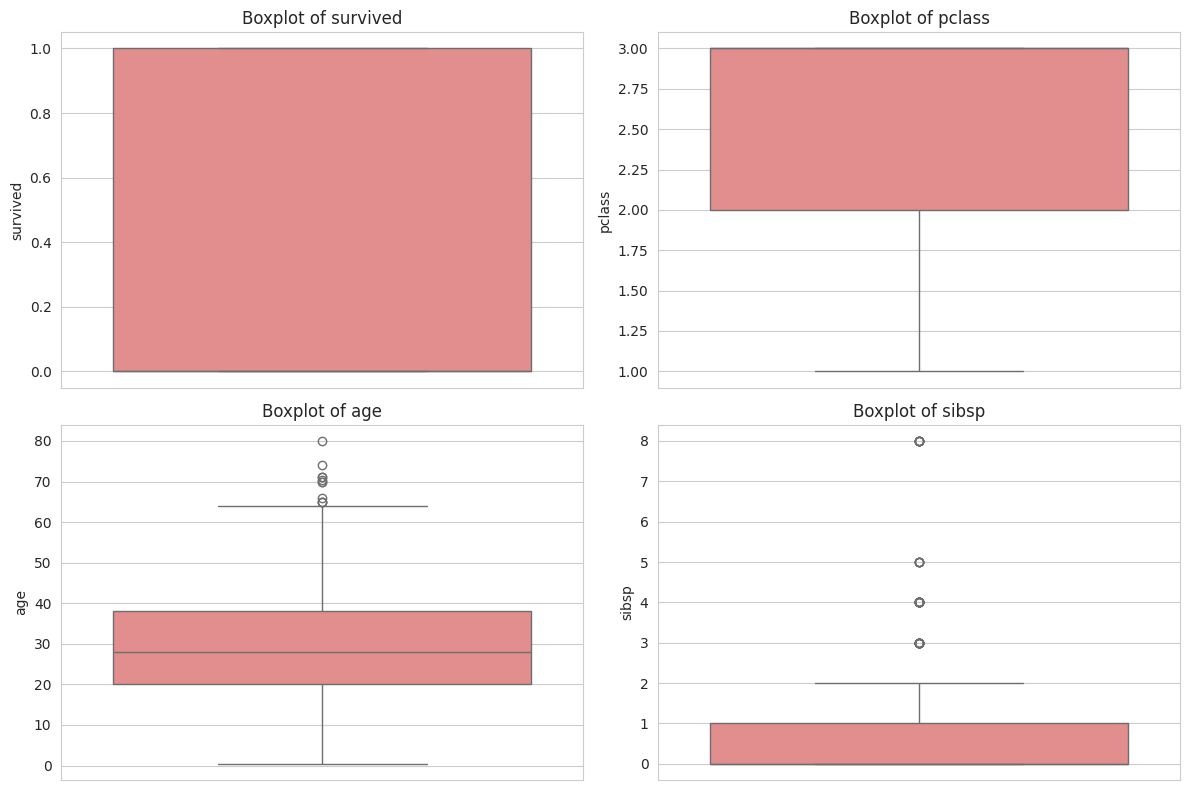

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

fig5, axes5 = plt.subplots(2, 2, figsize=(12, 8))

for i, col in enumerate(num_cols[:4]):
    row, colpos = divmod(i, 2)

    sns.boxplot(
        y=df[col].dropna(),
        ax=axes5[row, colpos],
        color='lightcoral'
    )

    axes5[row, colpos].set_title(f'Boxplot of {col}')
    axes5[row, colpos].set_xlabel('')
    axes5[row, colpos].set_ylabel(col)

plt.tight_layout()
plt.show()

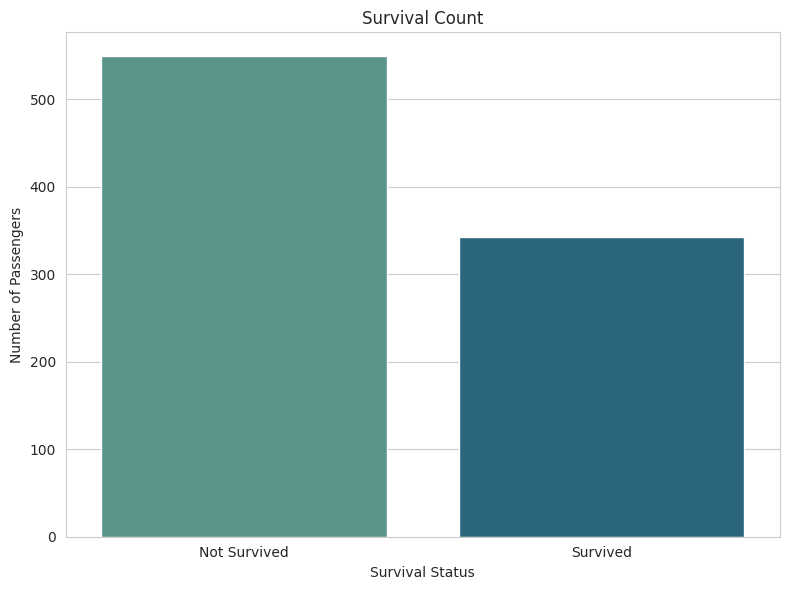


Survival Count:
survived
0    549
1    342
Name: count, dtype: int64


In [17]:
fig4 = plt.figure(figsize=(8, 6))

survival_count = df['survived'].value_counts().sort_index()

sns.barplot(
    x=['Not Survived', 'Survived'],
    y=survival_count.values,
    hue=['Not Survived', 'Survived'],
    palette="crest",
    legend=False
)

plt.title('Survival Count')
plt.xlabel('Survival Status')
plt.ylabel('Number of Passengers')
plt.tight_layout()
plt.show()

print("\nSurvival Count:")
print(survival_count)

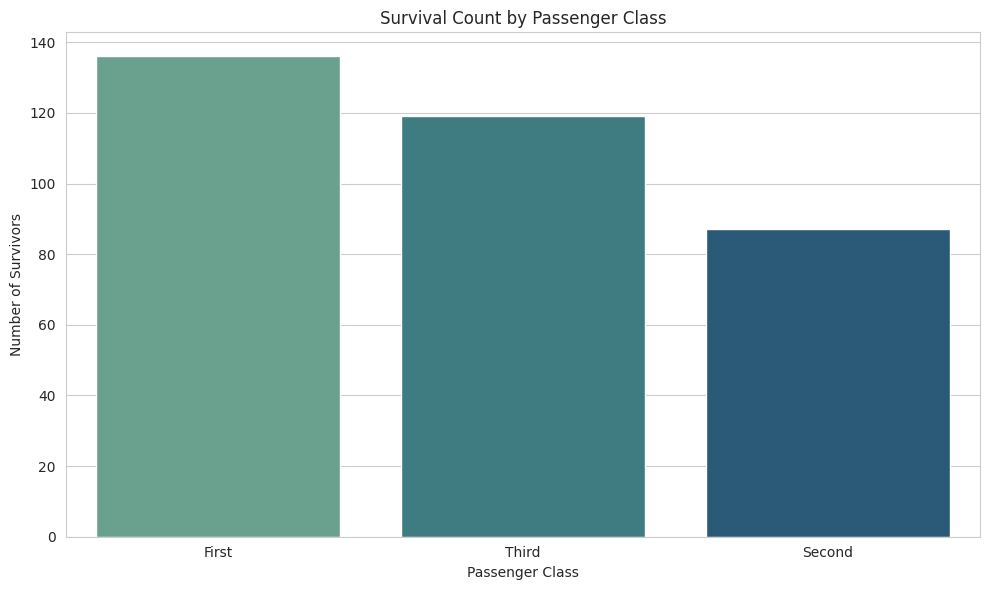


Survival Count by Passenger Class:
class
First     136
Third     119
Second     87
dtype: int64


In [18]:
fig5 = plt.figure(figsize=(10, 6))

survival_count_class = (
    df[df['survived'] == 1]
    .groupby('class')
    .size()
    .sort_values(ascending=False)
)

sns.barplot(
    x=survival_count_class.index,
    y=survival_count_class.values,
    hue=survival_count_class.index,
    palette="crest",
    legend=False
)

plt.title('Survival Count by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Survivors')
plt.tight_layout()
plt.show()

print("\nSurvival Count by Passenger Class:")
print(survival_count_class)

In [21]:
pdf = PdfPages('Titanic_EDA_Report.pdf')

pdf.savefig(fig1)   # Page 1: Missingness Heatmap
pdf.savefig(fig2)   # Page 2: Numerical Distributions
pdf.savefig(fig3)   # Page 3: Survival Rate by Gender
pdf.savefig(fig4)   # Page 4: Correlation Heatmap
pdf.savefig(fig5)   # Page 5: Boxplots


pdf.close()

print("\nTitanic_EDA_Report.pdf created successfully with 7 pages!")


Titanic_EDA_Report.pdf created successfully with 7 pages!


In [22]:
files.download('Titanic_EDA_Report.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>